<a href="https://colab.research.google.com/github/dominicwooldridge/GSB-S544/blob/Practice-Activities/Copy_of_Practice_Activity_Penguin_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `species` using the other variables in the dataset.

**Dummify** all variables that require this.

In [2]:
pip install palmerpenguins

In [3]:
# Code Here

from palmerpenguins import load_penguins

penguins = load_penguins()
print(penguins.head())


  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  


In [4]:
import pandas as pd

peng_clean = penguins.dropna()

y = peng_clean['species']

X = peng_clean.drop(columns=['species'])

X_dummies = pd.get_dummies(X, drop_first=True)

print(X_dummies.head())


   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  year  \
0            39.1           18.7              181.0       3750.0  2007   
1            39.5           17.4              186.0       3800.0  2007   
2            40.3           18.0              195.0       3250.0  2007   
4            36.7           19.3              193.0       3450.0  2007   
5            39.3           20.6              190.0       3650.0  2007   

   island_Dream  island_Torgersen  sex_male  
0         False              True      True  
1         False              True     False  
2         False              True     False  
4         False              True     False  
5         False              True      True  


Let's use the other variables to predict `species`. Prepare your data and fit the following models on the entire dataset:

* Two kNN models (for different values of K)
* Two decision tree models (for different complexities of trees)

Compute the following, for each of your models, on test data. Keep in mind that you may need to stratify your creation of the training and test data.

* Confusion matrix
* Overall Accuracy
* Precision, Recall, AUC, and F1-score for each species

Create one ROC plot for the species of your choice.

In [5]:
# Code Here
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_dummies, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

class_names = sorted(y.unique())
print("Classes:", class_names)

Classes: ['Adelie', 'Chinstrap', 'Gentoo']


In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "kNN (k=3)":   KNeighborsClassifier(n_neighbors=3),
    "kNN (k=15)":  KNeighborsClassifier(n_neighbors=15),
    "Tree (depth=3)":  DecisionTreeClassifier(max_depth=3, random_state=42),
    "Tree (no depth limit)": DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)


In [7]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

def evaluate_model(name, model, X_test, y_test, class_names):
    print(f"\n=== {name} ===")

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    print("\nConfusion Matrix (rows = true, cols = predicted):")
    print(pd.DataFrame(cm, index=class_names, columns=class_names))

    # Overall accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\nOverall Accuracy: {acc:.3f}")

    # Precision, Recall, F1 per class
    prec, rec, f1, support = precision_recall_fscore_support(
        y_test, y_pred, labels=class_names, zero_division=0
    )
    prf_table = pd.DataFrame({
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Support": support
    }, index=class_names)
    print("\nPrecision / Recall / F1 per species:")
    print(prf_table)

    # AUC per class (one-vs-rest)
    y_test_bin = label_binarize(y_test, classes=class_names)  # shape (n_samples, n_classes)

    aucs = {}
    for i, cls in enumerate(class_names):
        aucs[cls] = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    print("\nAUC per species (one-vs-rest):")
    for cls, auc in aucs.items():
        print(f"  {cls}: {auc:.3f}")

    return {
        "name": name,
        "accuracy": acc,
        "prf_table": prf_table,
        "aucs": aucs,
        "y_test_bin": y_test_bin,
        "y_proba": y_proba
    }


In [8]:
results = {}

for name, model in models.items():
    results[name] = evaluate_model(name, model, X_test, y_test, class_names)



=== kNN (k=3) ===

Confusion Matrix (rows = true, cols = predicted):
           Adelie  Chinstrap  Gentoo
Adelie         37          4       3
Chinstrap       9         10       1
Gentoo          4          0      32

Overall Accuracy: 0.790

Precision / Recall / F1 per species:
           Precision    Recall  F1-score  Support
Adelie      0.740000  0.840909  0.787234       44
Chinstrap   0.714286  0.500000  0.588235       20
Gentoo      0.888889  0.888889  0.888889       36

AUC per species (one-vs-rest):
  Adelie: 0.870
  Chinstrap: 0.801
  Gentoo: 0.953

=== kNN (k=15) ===

Confusion Matrix (rows = true, cols = predicted):
           Adelie  Chinstrap  Gentoo
Adelie         38          2       4
Chinstrap      19          0       1
Gentoo          1          0      35

Overall Accuracy: 0.730

Precision / Recall / F1 per species:
           Precision    Recall  F1-score  Support
Adelie      0.655172  0.863636  0.745098       44
Chinstrap   0.000000  0.000000  0.000000       20
Gent

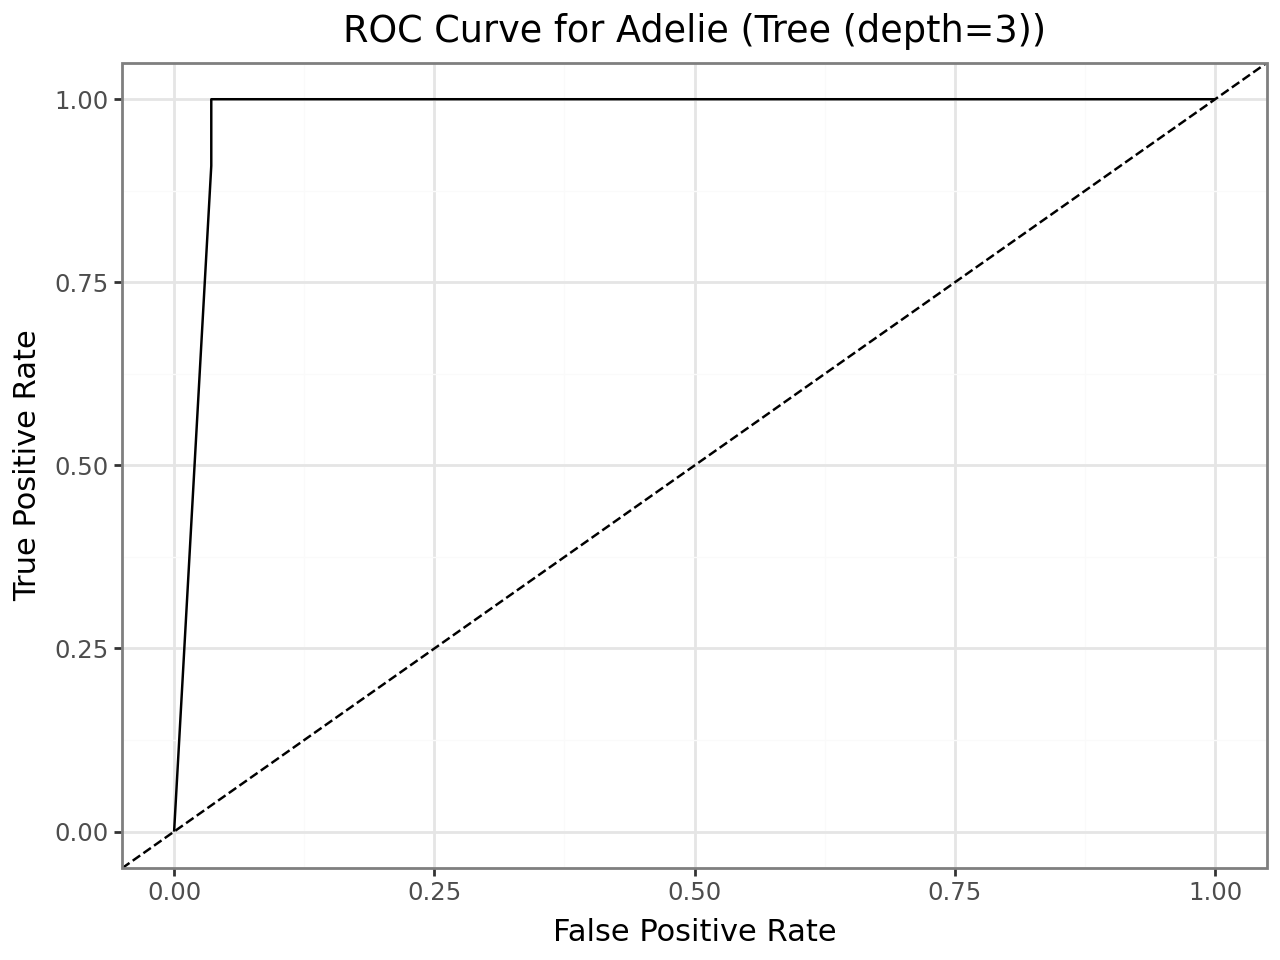

In [9]:
import pandas as pd
from sklearn.metrics import roc_curve
from plotnine import ggplot, aes, geom_line, geom_abline, labs, theme_bw

model_name_for_roc = "Tree (depth=3)"
species_for_roc = "Adelie"

res = results[model_name_for_roc]
y_test_bin = res["y_test_bin"]
y_proba    = res["y_proba"]

idx = class_names.index(species_for_roc)

fpr, tpr, thresholds = roc_curve(y_test_bin[:, idx], y_proba[:, idx])

roc_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr
})

p_roc = (
    ggplot(roc_df, aes(x="fpr", y="tpr"))
    + geom_line()
    + geom_abline(slope=1, intercept=0, linetype="dashed")
    + labs(
        title=f"ROC Curve for {species_for_roc} ({model_name_for_roc})",
        x="False Positive Rate",
        y="True Positive Rate"
    )
    + theme_bw()
)

p_roc
